In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/CLEAN_FIFA23_official_data.csv")
df.shape

(17660, 31)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17660 non-null  int64  
 1   ID                        17660 non-null  int64  
 2   Name                      17660 non-null  object 
 3   Age                       17660 non-null  int64  
 4   Photo                     17660 non-null  object 
 5   Nationality               17660 non-null  object 
 6   Flag                      17660 non-null  object 
 7   Overall                   17660 non-null  int64  
 8   Potential                 17660 non-null  int64  
 9   Club                      17660 non-null  object 
 10  Club Logo                 17660 non-null  object 
 11  Value(£)                  17660 non-null  float64
 12  Wage(£)                   17660 non-null  float64
 13  Special                   17660 non-null  int64  
 14  Prefer

In [18]:
df.isna().sum().sort_values(ascending=False)

,0
Loaned From,16966
Body Type,38
Unnamed: 0,0
Age,0
Photo,0
ID,0
Name,0
Overall,0
Potential,0
Club,0


In [19]:
df["Position"].unique()

array(['SUB', 'LCM', 'LB', 'RCM', 'RDM', 'LCB', 'RS', 'RB', 'LM', 'LS',
       'RWB', 'CDM', 'RW', 'RM', 'LF', 'LWB', 'ST', 'CAM', 'LDM', 'RES',
       'LW', 'CF', 'RF', 'RCB', 'CM', 'CB', 'RAM', 'LAM', 'GK'],
      dtype=object)

In [20]:
df["Position"].value_counts()

,count
Position,
SUB,7462
RES,5224
RCB,449
LCB,398
GK,376
ST,346
LB,330
RB,327
RCM,325


In [21]:
attacker_positions = ["ST", "CF", "LW", "RW", "LF", "RF"]

df["Position"] = df["Position"].astype(str)

attackers = df[df["Position"].apply(
    lambda x: any(tag in x.split(",") for tag in attacker_positions)
)].copy()

attackers.shape

(699, 31)

In [22]:
attackers = attackers[
    ["Name", "Age", "Nationality", "Club", "Position",
     "Overall", "Potential",
     "Value(£)", "Wage(£)"]
].copy()

attackers.head()

,Name,Age,Nationality,Club,Position,Overall,Potential,Value(£),Wage(£)
25,M. Salah,30,Egypt,Liverpool,RW,90,90,115500000.0,270000.0
35,R. Malinovskyi,29,Ukraine,Atalanta,LF,82,82,30500000.0,73000.0
41,R. Lewandowski,33,Poland,FC Barcelona,ST,91,91,84000000.0,420000.0
48,B. Bourigeaud,28,France,Stade Rennais FC,RW,81,81,26000000.0,66000.0
52,H. Kane,28,England,Tottenham Hotspur,ST,89,89,105500000.0,240000.0


In [23]:
def clean_currency(col):
    return (
        col.astype(str)
           .str.replace("£", "", regex=False)
           .str.replace("£", "", regex=False)
           .str.replace(",", "", regex=False)
           .astype(float)
    )

attackers["value_gbp"] = clean_currency(attackers["Value(£)"])
attackers["wage_gbp"] = clean_currency(attackers["Wage(£)"])

In [24]:
attackers[["Value(£)", "value_gbp", "Wage(£)", "wage_gbp"]].head()

,Value(£),value_gbp,Wage(£),wage_gbp
25,115500000.0,115500000.0,270000.0,270000.0
35,30500000.0,30500000.0,73000.0,73000.0
41,84000000.0,84000000.0,420000.0,420000.0
48,26000000.0,26000000.0,66000.0,66000.0
52,105500000.0,105500000.0,240000.0,240000.0


In [25]:
attackers.isna().sum()

,0
Name,0
Age,0
Nationality,0
Club,0
Position,0
Overall,0
Potential,0
Value(£),0
Wage(£),0
value_gbp,0


In [26]:
attackers = attackers.dropna(subset=["Overall", "value_gbp"])
attackers = attackers[attackers["value_gbp"] > 0]

attackers.shape

(689, 11)

In [40]:
# -----------------------------------------
# REGRESSION MODEL: PREDICT PLAYER MARKET VALUE
# -----------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Define the clean_currency function for use within this cell
def clean_currency(col):
    return (
        col.astype(str)
           .str.replace("£", "", regex=False)
           .str.replace(",", "", regex=False)
           .astype(float)
    )

# Re-create attackers DataFrame with all necessary columns from original df
# This step is added to ensure that the columns 'International Reputation', 'Skill Moves',
# 'Weak Foot', 'Height(cm.)', 'Weight(lbs.)' are present, as they were dropped in a
# previous cell's subsetting operation, but are required for this regression model
# and for consistency with later notebook cells.
attacker_positions = ["ST", "CF", "LW", "RW", "LF", "RF"]

# Ensure 'Position' is string type on a temporary copy to avoid modifying original df prematurely if it's not the goal
df_processed_pos = df.copy()
df_processed_pos["Position"] = df_processed_pos["Position"].astype(str)

# Filter the original df to get all columns for attackers
attackers = df_processed_pos[df_processed_pos["Position"].apply(
    lambda x: any(tag in x.split(",") for tag in attacker_positions)
)].copy()

# Add the 'value_gbp' and 'wage_gbp' columns for consistency with later notebook cells
attackers["value_gbp"] = clean_currency(attackers["Value(£)"])
attackers["wage_gbp"] = clean_currency(attackers["Wage(£)"])

# Select regression features from the (now correctly populated) attackers DataFrame
regression_df = attackers[[
    "Name",
    "Club",
    "Position",
    "Overall",
    "Potential",
    "Age",
    "International Reputation",
    "Skill Moves",
    "Weak Foot",
    "Height(cm.)",
    "Weight(lbs.)",
    "Value(£)"
]].copy()

# Remove any remaining missing values just in case
regression_df = regression_df.dropna()

# Features (X) and target (y)
X = regression_df[[
    "Overall",
    "Potential",
    "Age",
    "International Reputation",
    "Skill Moves",
    "Weak Foot",
    "Height(cm.)",
    "Weight(lbs.)"
]]

y = regression_df["Value(£)"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 7049551.817216288
R2 Score: 0.6709676382589146


In [28]:
# Add predictions back to the full regression dataset
regression_df["Predicted_Value"] = model.predict(X)

# Calculate mispricing
regression_df["Value_Difference"] = regression_df["Predicted_Value"] - regression_df["Value(£)"]

# Positive = potentially undervalued
# Negative = potentially overpriced

undervalued_players = regression_df.sort_values("Value_Difference", ascending=False)
overpriced_players = regression_df.sort_values("Value_Difference", ascending=True)

print("Top 10 potentially undervalued attackers")
display(undervalued_players[[
    "Name", "Club", "Position", "Overall", "Potential",
    "Value(£)", "Predicted_Value", "Value_Difference"
]].head(10))

print("Top 10 potentially overpriced attackers")
display(overpriced_players[[
    "Name", "Club", "Position", "Overall", "Potential",
    "Value(£)", "Predicted_Value", "Value_Difference"
]].head(10))

Top 10 potentially undervalued attackers


,Name,Club,Position,Overall,Potential,Value(£),Predicted_Value,Value_Difference
2250,M. Balotelli,Adana Demirspor,ST,77,77,9000000.0,4.035160e+07,3.135160e+07
3647,16 M. Klose,Lazio,ST,79,79,1300000.0,3.097874e+07,2.967874e+07
3836,G. Higuaín,Inter Miami CF,ST,75,75,2700000.0,3.186816e+07,2.916816e+07
148,21 Hulk,Shanghai Port FC,LW,80,80,13000000.0,3.905523e+07,2.605523e+07
435,A. Ayew,Manchester United,ST,75,75,0.0,2.368231e+07,2.368231e+07
132,Á. Di María,Juventus,RW,84,84,20000000.0,4.345349e+07,2.345349e+07
3122,G. Zardes,Colorado Rapids,ST,71,71,1800000.0,2.416944e+07,2.236944e+07
356,M. Götze,Eintracht Frankfurt,LF,81,81,25000000.0,4.621205e+07,2.121205e+07
10541,10 N. Frutos,RSC Anderlecht,ST,75,78,0.0,2.050093e+07,2.050093e+07
1740,22 Alex Teixeira,Beşiktaş JK,LW,76,76,6000000.0,2.630452e+07,2.030452e+07


Top 10 potentially overpriced attackers


,Name,Club,Position,Overall,Potential,Value(£),Predicted_Value,Value_Difference
75,K. Mbappé,Paris Saint-Germain,ST,91,95,190500000.0,7.012969e+07,-1.203703e+08
180,E. Haaland,Manchester City,ST,88,94,148000000.0,7.046202e+07,-7.753798e+07
849,Vinícius Jr.,Real Madrid CF,LW,86,92,109000000.0,4.203454e+07,-6.696546e+07
317,P. Foden,Manchester City,RW,85,92,109500000.0,4.966955e+07,-5.983045e+07
25,M. Salah,Liverpool,RW,90,90,115500000.0,5.714887e+07,-5.835113e+07
1561,D. Vlahović,Juventus,ST,84,91,86500000.0,4.030601e+07,-4.619399e+07
52,H. Kane,Tottenham Hotspur,ST,89,89,105500000.0,6.052319e+07,-4.497681e+07
60,S. Mané,FC Bayern München,ST,89,89,99500000.0,5.564711e+07,-4.385289e+07
135,H. Son,Tottenham Hotspur,LW,89,89,101000000.0,5.836659e+07,-4.263341e+07
966,Rafael Leão,AC Milan,LW,84,90,66500000.0,2.592514e+07,-4.057486e+07


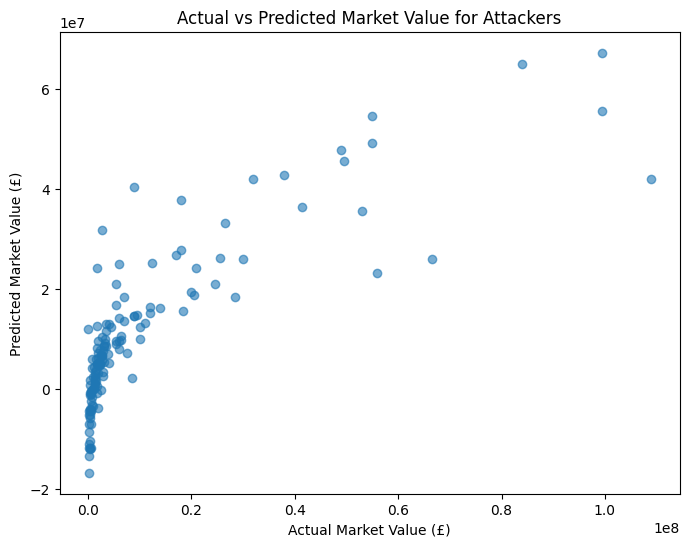

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Market Value (£)")
plt.ylabel("Predicted Market Value (£)")
plt.title("Actual vs Predicted Market Value for Attackers")
plt.show()

In [42]:
attacker_positions = ["ST", "CF", "LW", "RW", "LF", "RF"]
attackers = df[df["Position"].isin(attacker_positions)].copy()

In [43]:
What R² score did you get?

Object `get` not found.


In [30]:
print("Original df:", df.shape)
print("Attackers df:", attackers.shape)
attackers.head()

Original df: (17660, 31)
Attackers df: (699, 33)


,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Loaned From,Contract Valid Until,Height(cm.),Weight(lbs.),Release Clause(£),Kit Number,Best Overall Rating,Year_Joined,value_gbp,wage_gbp
25,25,209331,M. Salah,30,https://cdn.sofifa.net/players/209/331/23_60.png,Egypt,https://cdn.sofifa.net/flags/eg.png,90,90,Liverpool,...,NaN,2023.0,175.0,156.555,213700000.0,11.0,0.0,2017,115500000.0,270000.0
35,35,231969,R. Malinovskyi,29,https://cdn.sofifa.net/players/231/969/23_60.png,Ukraine,https://cdn.sofifa.net/flags/ua.png,82,82,Atalanta,...,NaN,2023.0,181.0,174.195,51900000.0,18.0,0.0,2019,30500000.0,73000.0
41,41,188545,R. Lewandowski,33,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,https://cdn.sofifa.net/flags/pl.png,91,91,FC Barcelona,...,NaN,2025.0,185.0,178.605,172200000.0,9.0,0.0,2022,84000000.0,420000.0
48,48,214097,B. Bourigeaud,28,https://cdn.sofifa.net/players/214/097/23_60.png,France,https://cdn.sofifa.net/flags/fr.png,81,81,Stade Rennais FC,...,NaN,2023.0,178.0,149.940,49400000.0,14.0,0.0,2017,26000000.0,66000.0
52,52,202126,H. Kane,28,https://cdn.sofifa.net/players/202/126/23_60.png,England,https://cdn.sofifa.net/flags/gb-eng.png,89,89,Tottenham Hotspur,...,NaN,2024.0,188.0,196.245,200500000.0,10.0,0.0,2010,105500000.0,240000.0


In [31]:
attackers[["Overall", "Potential", "value_gbp", "wage_gbp"]].describe()

,Overall,Potential,value_gbp,wage_gbp
count,699.000000,699.00000,6.990000e+02,699.000000
mean,70.414878,74.30186,8.732790e+06,21671.959943
std,7.369853,6.90431,1.826177e+07,43617.855207
min,51.000000,56.00000,0.000000e+00,0.000000
25%,65.000000,70.00000,9.625000e+05,1000.000000
50%,70.000000,74.00000,2.100000e+06,6000.000000
75%,75.500000,79.00000,7.000000e+06,23000.000000
max,91.000000,95.00000,1.905000e+08,450000.000000


In [32]:
attackers["performance_score"] = 0.7*attackers["Overall"] + 0.3*attackers["Potential"]

In [33]:
attackers["value_score"] = attackers["performance_score"] / (attackers["value_gbp"] / 1_000_000)

In [34]:
attackers[["Name","Position","Overall","Potential","value_gbp","performance_score","value_score"]].head()

,Name,Position,Overall,Potential,value_gbp,performance_score,value_score
25,M. Salah,RW,90,90,115500000.0,90.0,0.779221
35,R. Malinovskyi,LF,82,82,30500000.0,82.0,2.688525
41,R. Lewandowski,ST,91,91,84000000.0,91.0,1.083333
48,B. Bourigeaud,RW,81,81,26000000.0,81.0,3.115385
52,H. Kane,ST,89,89,105500000.0,89.0,0.843602


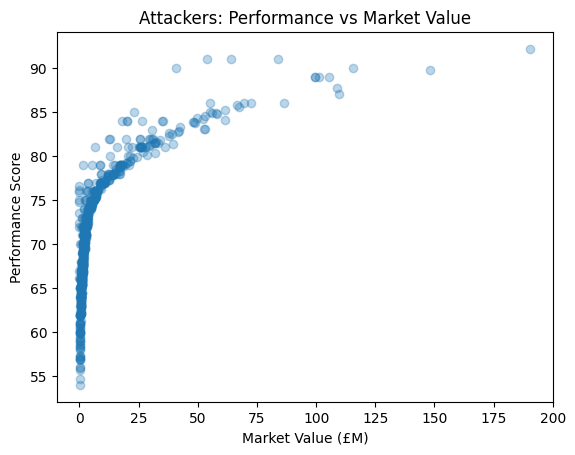

In [35]:
plt.figure()
plt.scatter(attackers["value_gbp"]/1_000_000, attackers["performance_score"], alpha=0.3)
plt.xlabel("Market Value (£M)")
plt.ylabel("Performance Score")
plt.title("Attackers: Performance vs Market Value")
plt.show()

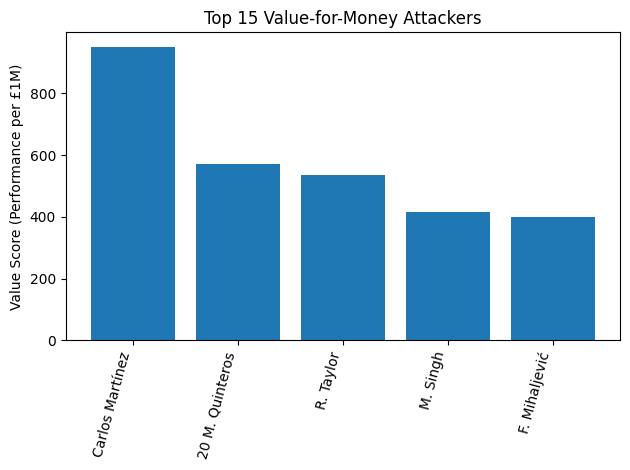

In [36]:
top15 = attackers.sort_values("value_score", ascending=False).head(15)

plt.figure()
plt.bar(top15["Name"], top15["value_score"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("Value Score (Performance per £1M)")
plt.title("Top 15 Value-for-Money Attackers")
plt.tight_layout()
plt.show()

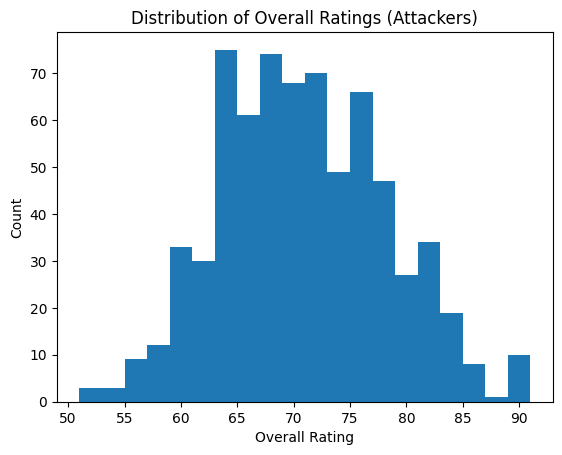

In [37]:
plt.figure()
plt.hist(attackers["Overall"], bins=20)
plt.xlabel("Overall Rating")
plt.ylabel("Count")
plt.title("Distribution of Overall Ratings (Attackers)")
plt.show()

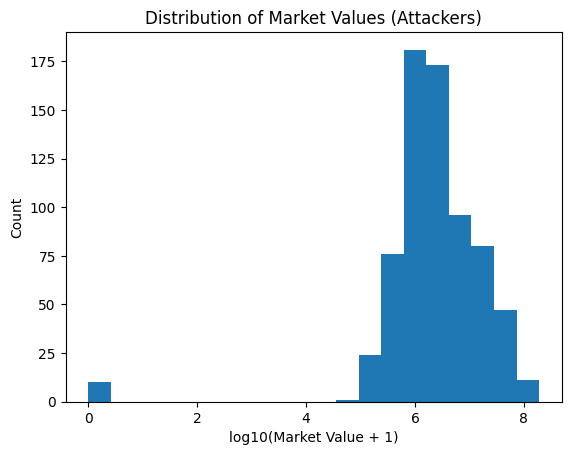

In [38]:
plt.figure()
plt.hist(np.log10(attackers["value_gbp"] + 1), bins=20)
plt.xlabel("log10(Market Value + 1)")
plt.ylabel("Count")
plt.title("Distribution of Market Values (Attackers)")
plt.show()

In [39]:
shortlist = attackers.sort_values(["value_score", "performance_score"], ascending=False).head(50)

shortlist_out = shortlist[
    ["Name", "Age", "Nationality", "Club", "Position",
     "Overall", "Potential",
     "value_gbp", "wage_gbp",
     "performance_score", "value_score"]
]

shortlist_out.to_csv("attackers_shortlist_top50.csv", index=False)
shortlist_out.head(10)

,Name,Age,Nationality,Club,Position,Overall,Potential,value_gbp,wage_gbp,performance_score,value_score
2521,A. Afif,25,Qatar,Manchester United,LW,76,78,0.0,0.0,76.6,inf
1646,22 A. Zakharyan,18,Russia,Manchester United,LW,72,86,0.0,0.0,76.2,inf
10541,10 N. Frutos,28,Argentina,RSC Anderlecht,ST,75,78,0.0,0.0,75.9,inf
435,A. Ayew,32,Ghana,Manchester United,ST,75,75,0.0,0.0,75.0,inf
2597,21 K. Despodov,23,Bulgaria,Manchester United,LF,73,79,0.0,0.0,74.8,inf
5394,A. Ali,25,Qatar,Manchester United,ST,72,77,0.0,0.0,73.5,inf
3392,11 D. Moreira,32,France,US Boulogne Cote D'Opale,RW,70,78,0.0,0.0,72.4,inf
3877,H. Al Haydos,31,Qatar,Manchester United,RW,72,72,0.0,0.0,72.0,inf
4539,21 D. Iliev,31,Bulgaria,Manchester United,ST,67,67,0.0,0.0,67.0,inf
8606,21 G. Yomov,22,Bulgaria,Manchester United,RF,64,71,0.0,0.0,66.1,inf
